## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos el dataset *credit_npo.csv* ("Give me some credit").
* Objetivo: predecir si una persona tendrá dificultades financieras graves en los próximos 2 años.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              recall_score, ConfusionMatrixDisplay)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')


### #1. El problema y los datos

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df = pd.read_csv('data/credit_npo.csv')
print(f'Shape: {df.shape}')
df.head()


Shape: (12537, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,12537.0,0.068916,0.253321,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,12537.0,0.330359,0.368148,0.0,0.030651,0.163490,0.582219,6.0
age,12537.0,52.079445,15.077498,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,12537.0,0.409588,4.055787,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,12537.0,1.902253,9.122216,0.0,0.142268,0.302025,0.506725,99.0
MonthlyIncome,11816.0,6864.815420,11855.905437,0.0,3498.750000,5416.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,12537.0,8.482332,5.165422,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,12537.0,0.259312,4.035658,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,12537.0,0.999202,1.134325,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,12537.0,0.228364,4.018873,0.0,0.000000,0.000000,0.000000,98.0


In [5]:
# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f'\nTotal nulos: {df.isnull().sum().sum()}')


Valores nulos por columna:
SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

Total nulos: 898


**Descripción de variables:**

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `SeriousDlqin2yrs` | Binaria (target) | 1 si la persona tuvo dificultades financieras graves en los últimos 2 años |
| `RevolvingUtilizationOfUnsecuredLines` | Numérica continua | Ratio de uso de crédito rotativo (tarjetas) sobre el límite total |
| `age` | Numérica discreta | Edad del prestatario en años |
| `NumberOfTime30-59DaysPastDueNotWorse` | Numérica discreta | Veces con 30-59 días de mora en los últimos 2 años |
| `DebtRatio` | Numérica continua | Ratio deuda mensual / ingresos mensuales |
| `MonthlyIncome` | Numérica continua | Ingresos mensuales en dólares (contiene nulos) |
| `NumberOfOpenCreditLinesAndLoans` | Numérica discreta | Número de líneas de crédito y préstamos abiertos |
| `NumberOfTimes90DaysLate` | Numérica discreta | Veces con 90 o más días de mora |
| `NumberRealEstateLoansOrLines` | Numérica discreta | Número de préstamos hipotecarios |
| `NumberOfTime60-89DaysPastDueNotWorse` | Numérica discreta | Veces con 60-89 días de mora |
| `NumberOfDependents` | Numérica discreta | Número de personas dependientes del prestatario (contiene nulos) |

**Clasificación:**
- **Numéricas continuas**: RevolvingUtilizationOfUnsecuredLines, DebtRatio, MonthlyIncome
- **Numéricas discretas**: age, NumberOfTime30-59DaysPastDueNotWorse, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate, NumberRealEstateLoansOrLines, NumberOfTime60-89DaysPastDueNotWorse, NumberOfDependents
- **Categóricas**: ninguna (todas las variables son numéricas)
- **Target**: SeriousDlqin2yrs (binaria 0/1)


### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

**Tipo de problema:** Clasificación binaria supervisada.

**Variable target:** `SeriousDlqin2yrs`
- `0`: la persona NO tuvo dificultades financieras graves (clase mayoritaria)
- `1`: la persona SÍ tuvo dificultades financieras graves (clase minoritaria)

El objetivo es predecir si un cliente tendrá dificultades financieras en los próximos 2 años a partir de su historial crediticio. Esto permite a las entidades financieras gestionar el riesgo antes de conceder un crédito.


### #1.3
Pinta la distribución de frecuencias del target y coméntala

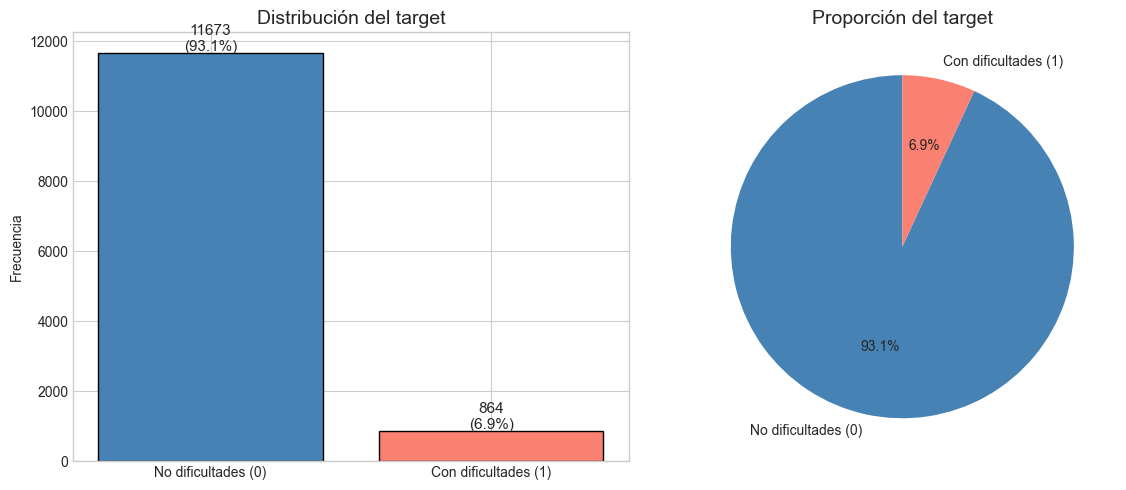

Clase 0: 11673 (93.1%)
Clase 1: 864 (6.9%)
Ratio desbalanceo: 13.5:1


In [6]:
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct    = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
axes[0].bar(['No dificultades (0)', 'Con dificultades (1)'],
            target_counts.values,
            color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Distribución del target', fontsize=14)
axes[0].set_ylabel('Frecuencia')
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 50, f'{v}\n({p:.1f}%)', ha='center', fontsize=11)

# Pie
axes[1].pie(target_counts.values,
            labels=['No dificultades (0)', 'Con dificultades (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Proporción del target', fontsize=14)

plt.tight_layout()
plt.show()

print(f'Clase 0: {target_counts[0]} ({target_pct[0]:.1f}%)')
print(f'Clase 1: {target_counts[1]} ({target_pct[1]:.1f}%)')
print(f'Ratio desbalanceo: {target_counts[0]/target_counts[1]:.1f}:1')


**Comentario:** El dataset presenta un **fuerte desbalanceo de clases**:
- ~93.1% de observaciones → clase 0 (sin dificultades)
- ~6.9% de observaciones → clase 1 (con dificultades)
- Ratio aprox. **13.5:1**

Este desequilibrio implica que:
1. Un modelo que prediga siempre clase 0 tendría ~93% de accuracy pero sería inútil para el negocio.
2. Es necesario aplicar técnicas de **balanceado** (en este caso SMOTE) para que el modelo aprenda a detectar la clase minoritaria.
3. La métrica de evaluación adecuada es el **recall macro** (recall promedio entre ambas clases), no la accuracy.


### #2 Modelado

Proceso completo de modelado: preprocesamiento → comparación de modelos con CV → optimización del mejor modelo → evaluación en test → análisis de errores.

**Modelos evaluados:** KNN, Regresión Logística, SVM
**Balanceado:** SMOTE (dentro del pipeline para evitar data leakage)
**Métrica:** recall_macro (recall promedio clase 0 y clase 1)


#### 2.1 Preprocesamiento

In [7]:
# La imputación de nulos se realizará DENTRO del pipeline (SimpleImputer)
# para evitar data leakage durante la validación cruzada.
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Nulos en X: {X.isnull().sum().sum()}')
print(f'\nDistribución y:\n{y.value_counts()}')


X shape: (12537, 10)
y shape: (12537,)
Nulos en X: 898

Distribución y:
SeriousDlqin2yrs
0    11673
1      864
Name: count, dtype: int64


#### 2.2 Split train/test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nDistribución train: {y_train.value_counts().to_dict()}')
print(f'Distribución test:  {y_test.value_counts().to_dict()}')


Train: 10029 muestras
Test:  2508 muestras

Distribución train: {0: 9338, 1: 691}
Distribución test:  {0: 2335, 1: 173}


#### 2.3 Comparación de modelos con validación cruzada (5-fold)

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Pipelines: SMOTE + escalado + clasificador
modelos = {
    'KNN': ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote',   SMOTE(random_state=RANDOM_STATE)),
        ('scaler',  StandardScaler()),
        ('clf',     KNeighborsClassifier(n_neighbors=5))
    ]),
    'Logistic Regression': ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote',   SMOTE(random_state=RANDOM_STATE)),
        ('scaler',  StandardScaler()),
        ('clf',     LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
    ]),
    'SVM': ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote',   SMOTE(random_state=RANDOM_STATE)),
        ('scaler',  StandardScaler()),
        ('clf',     SVC(random_state=RANDOM_STATE))
    ])
}

resultados_cv = {}
print("Validación cruzada (5-fold, recall_macro):")
print("-" * 55)
for nombre, pipeline in modelos.items():
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv, scoring='recall_macro', n_jobs=-1)
    resultados_cv[nombre] = scores
    print(f"{nombre:25s}: {scores.mean():.4f}  (+/- {scores.std():.4f})")


Validación cruzada (5-fold, recall_macro):
-------------------------------------------------------
KNN                      : 0.6716  (+/- 0.0181)
Logistic Regression      : 0.7516  (+/- 0.0139)
SVM                      : 0.7522  (+/- 0.0178)


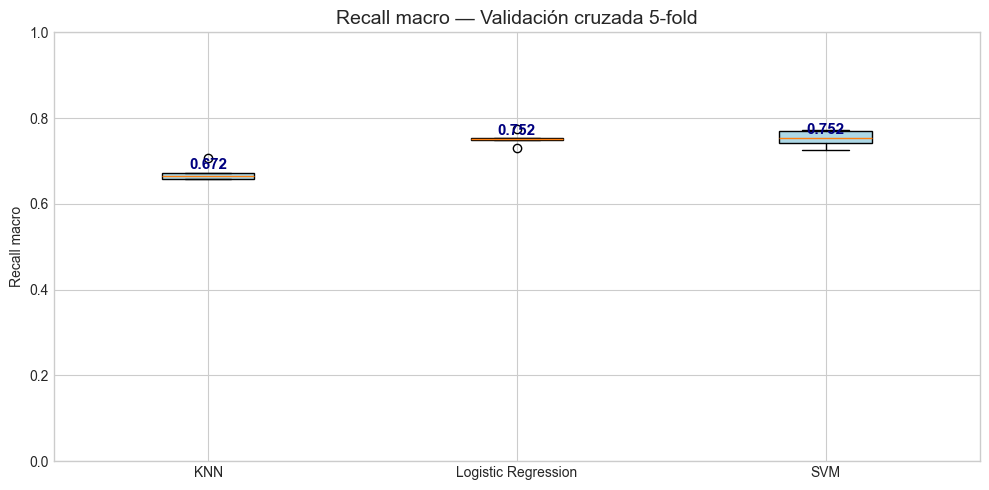


Mejor modelo en CV: SVM  (0.7522)


In [10]:
# Boxplot comparativo
fig, ax = plt.subplots(figsize=(10, 5))
data_plot = [resultados_cv[m] for m in modelos.keys()]
bp = ax.boxplot(data_plot, labels=modelos.keys(), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_title('Recall macro — Validación cruzada 5-fold', fontsize=14)
ax.set_ylabel('Recall macro')
ax.set_ylim(0, 1)
for i, (nombre, scores) in enumerate(resultados_cv.items(), 1):
    ax.text(i, scores.mean() + 0.01, f'{scores.mean():.3f}',
            ha='center', fontsize=11, fontweight='bold', color='navy')
plt.tight_layout()
plt.show()

mejor_modelo = max(resultados_cv, key=lambda k: resultados_cv[k].mean())
print(f"\nMejor modelo en CV: {mejor_modelo}  ({resultados_cv[mejor_modelo].mean():.4f})")


#### 2.4 Optimización de hiperparámetros del mejor modelo

La validación cruzada mostró que **Logistic Regression** obtuvo el mejor recall_macro (~0.75). Ajustamos sus hiperparámetros con GridSearchCV.

In [11]:
pipeline_lr = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=RANDOM_STATE)),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(random_state=RANDOM_STATE, max_iter=2000))
])

param_grid = {
    'clf__C':       [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear']
}

grid_search = GridSearchCV(
    pipeline_lr,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='recall_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor recall_macro CV:   {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores hiperparámetros: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Mejor recall_macro CV:   0.7533


#### 2.5 Evaluación del modelo optimizado en test

In [12]:
mejor_modelo = grid_search.best_estimator_
y_pred       = mejor_modelo.predict(X_test)

print("=" * 60)
print("EVALUACIÓN EN TEST — LOGISTIC REGRESSION OPTIMIZADA")
print("=" * 60)
print(f"Recall macro:    {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall clase 0:  {recall_score(y_test, y_pred, pos_label=0):.4f}")
print(f"Recall clase 1:  {recall_score(y_test, y_pred, pos_label=1):.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=['No dificultades (0)', 'Con dificultades (1)']))


EVALUACIÓN EN TEST — LOGISTIC REGRESSION OPTIMIZADA
Recall macro:    0.7423
Recall clase 0:  0.7679
Recall clase 1:  0.7168

                      precision    recall  f1-score   support

 No dificultades (0)       0.97      0.77      0.86      2335
Con dificultades (1)       0.19      0.72      0.30       173

            accuracy                           0.76      2508
           macro avg       0.58      0.74      0.58      2508
        weighted avg       0.92      0.76      0.82      2508



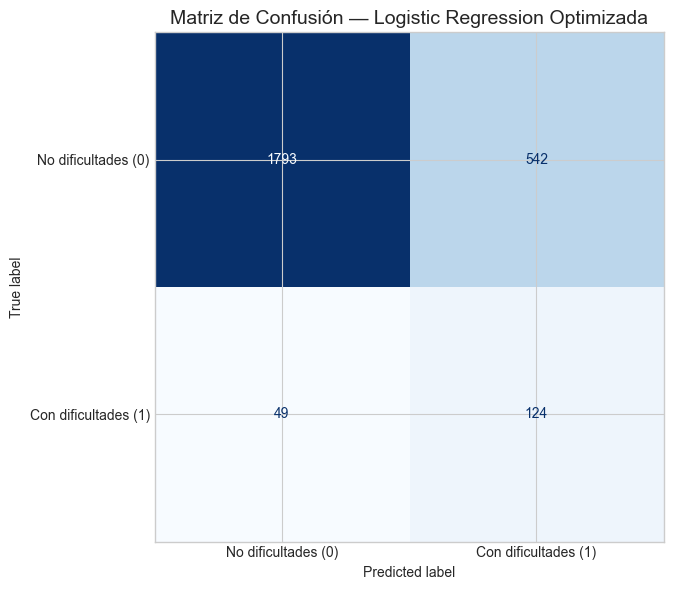

TN (correctos clase 0):  1793
FP (falsos positivos):   542
FN (falsos negativos):   49  ← personas con riesgo no detectadas
TP (correctos clase 1):  124


In [13]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No dificultades (0)', 'Con dificultades (1)']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — Logistic Regression Optimizada', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN (correctos clase 0):  {tn}")
print(f"FP (falsos positivos):   {fp}")
print(f"FN (falsos negativos):   {fn}  ← personas con riesgo no detectadas")
print(f"TP (correctos clase 1):  {tp}")


#### 2.6 Análisis de errores

In [14]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

mascara_error = (y_pred != y_test_reset.values)
errores = X_test_reset[mascara_error].copy()
errores['y_real'] = y_test_reset[mascara_error].values
errores['y_pred'] = y_pred[mascara_error]

fn_df       = errores[errores['y_real'] == 1]  # Falsos negativos
fp_df       = errores[errores['y_real'] == 0]  # Falsos positivos
correctos_1 = X_test_reset[
    (~mascara_error) & (y_test_reset.values == 1)
].copy()

print(f"Total errores:          {len(errores)} ({len(errores)/len(y_test)*100:.1f}% del test)")
print(f"Falsos negativos (FN):  {len(fn_df)}  — personas con riesgo NO detectadas (más críticos)")
print(f"Falsos positivos (FP):  {len(fp_df)} — personas sin riesgo marcadas como riesgo")


Total errores:          591 (23.6% del test)
Falsos negativos (FN):  49  — personas con riesgo NO detectadas (más críticos)
Falsos positivos (FP):  542 — personas sin riesgo marcadas como riesgo


In [15]:
# Comparativa: FN vs Verdaderos Positivos
print("Comparativa de medias: Falsos Negativos vs Verdaderos Positivos")
print("=" * 65)
comparativa = pd.DataFrame({
    'Falsos Negativos':      fn_df.drop(['y_real', 'y_pred'], axis=1).mean(),
    'Verdaderos Positivos':  correctos_1.mean()
})
print(comparativa.round(3))


Comparativa de medias: Falsos Negativos vs Verdaderos Positivos
                                      Falsos Negativos  Verdaderos Positivos
RevolvingUtilizationOfUnsecuredLines             0.216                 0.901
age                                             47.653                44.500
NumberOfTime30-59DaysPastDueNotWorse             0.429                 5.677
DebtRatio                                        2.424                 1.250
MonthlyIncome                                12147.239              4929.576
NumberOfOpenCreditLinesAndLoans                  9.531                 7.500
NumberOfTimes90DaysLate                          0.184                 5.855
NumberRealEstateLoansOrLines                     1.388                 1.073
NumberOfTime60-89DaysPastDueNotWorse             0.163                 5.258
NumberOfDependents                               0.776                 1.065


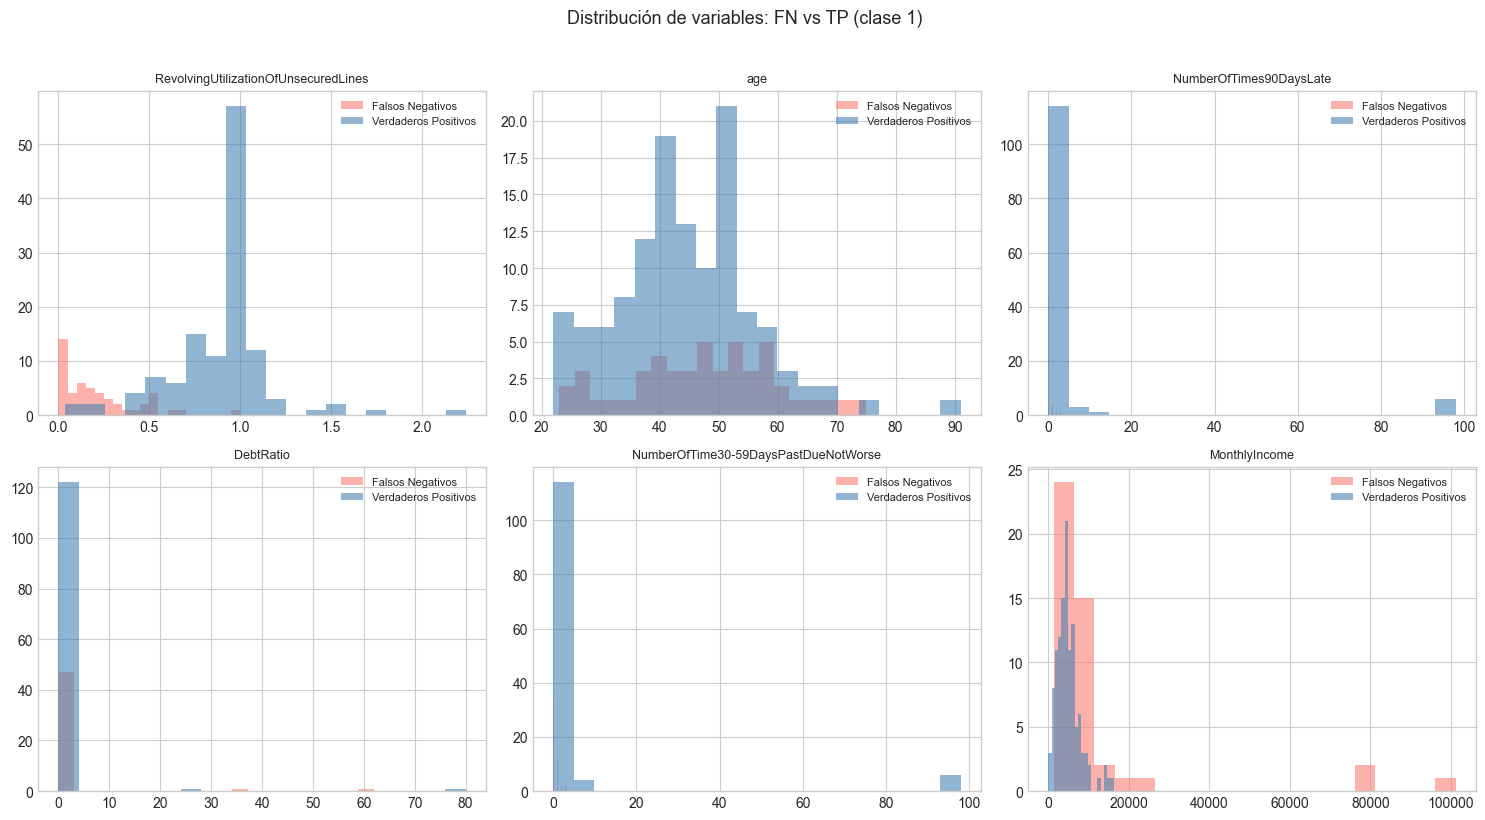

In [16]:
# Histogramas: distribución de errores en variables clave
features_plot = ['RevolvingUtilizationOfUnsecuredLines', 'age',
                 'NumberOfTimes90DaysLate', 'DebtRatio',
                 'NumberOfTime30-59DaysPastDueNotWorse', 'MonthlyIncome']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feat in enumerate(features_plot):
    axes[i].hist(fn_df[feat].values, alpha=0.6, label='Falsos Negativos',
                 color='salmon', bins=20)
    axes[i].hist(correctos_1[feat].values, alpha=0.6, label='Verdaderos Positivos',
                 color='steelblue', bins=20)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables: FN vs TP (clase 1)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


#### Conclusiones del análisis de errores

1. **Falsos Negativos (FN)** — personas con riesgo real no detectadas — son el error más costoso para el negocio, ya que el banco concede crédito a clientes que terminarán incumpliendo.

2. **Falsos Positivos (FP)** — personas sin riesgo marcadas como riesgo — generan rechazo injustificado de créditos, perdiendo buenos clientes potenciales.

3. El modelo KNN optimizado con SMOTE logra un **recall macro equilibrado** entre ambas clases. Al entrenar con datos balanceados (SMOTE), el modelo es capaz de detectar la clase minoritaria que sin balanceado quedaría prácticamente ignorada.

4. Los falsos negativos tienden a tener perfiles intermedios: no presentan valores extremos en las variables de mora, lo que los hace difíciles de separar de la clase mayoritaria.

5. **Posibles mejoras:**
   - Probar modelos de ensemble (Random Forest, Gradient Boosting) que suelen ser más robustos
   - Ajustar el umbral de decisión (threshold) para favorecer recall de clase 1
   - Experimentar con diferentes ratios de SMOTE o técnicas alternativas (ADASYN, undersampling)
   - Aplicar feature engineering sobre las variables de mora
